In [1]:
import os
import qsprpred
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

import torch

from qsprpred.data import QSPRDataset, RandomSplit
from qsprpred.data.descriptors.fingerprints import MorganFP
import pandas as pd
from qsprpred.data.descriptors.sets import RDKitDescs
from MolEval import MolEmb 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import numpy as np
import pandas as pd
from sklearn.feature_selection import VarianceThreshold
from qsprpred.data.descriptors.sets import RDKitDescs

/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'torch_geometric'
Skipped loading modules with pytorch-geometric dependency, missing a depende

In [2]:
X1 = pd.read_csv("A2AR/mod_data/X1.1", index_col="QSPRID")
X2 = pd.read_csv("A2AR/mod_data/X2.1", index_col="QSPRID")
X3 = pd.read_csv("A2AR/mod_data/X3.1", index_col="QSPRID")
y1 = pd.read_csv("A2AR/mod_data/y1.1", index_col="QSPRID")
y2 = pd.read_csv("A2AR/mod_data/y2.1", index_col="QSPRID")
y3 = pd.read_csv("A2AR/mod_data/y3.1", index_col="QSPRID")


In [3]:
X1.columns = X1.columns.astype(str)
X2.columns = X2.columns.astype(str)
X3.columns = X3.columns.astype(str)

imp_mean = SimpleImputer(missing_values=pd.NA, strategy='mean')
X1 = imp_mean.fit_transform(X1)
X2 = imp_mean.transform(X2)
X3 = imp_mean.transform(X3)
scaler = StandardScaler()
scaler.fit(X1)
X1 = scaler.transform(X1)
X2 = scaler.transform(X2)
X3 = scaler.transform(X3)

In [4]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy=1, random_state=42)
X1, y1 = smote.fit_resample(X1, y1)
display(pd.DataFrame(X1))

,0,1,2,3,4,5,6,7,8,9,...,3066,3067,3068,3069,3070,3071,3072,3073,3074,3075
0,0.629350,0.409822,0.114763,0.849649,-1.302256,-1.582738,-0.678928,-1.233195,-1.434335,-1.134524,...,-0.081803,-0.341777,-0.116076,-0.184214,-0.057747,-0.310778,-0.239901,-0.195451,-0.279983,1.233341
1,1.225274,0.942670,-0.168389,-0.169440,-0.341978,-0.052202,2.212653,0.803415,0.814574,0.266891,...,-0.081803,-0.341777,-0.116076,-0.184214,-0.057747,-0.310778,-0.239901,4.974340,-0.279983,-1.882446
2,-0.982475,0.726753,-1.033329,1.253848,-0.652347,0.063208,0.950025,-0.664100,-1.904197,-1.753757,...,-0.081803,2.465924,-0.116076,-0.184214,-0.057747,-0.310778,-0.239901,-0.195451,-0.279983,2.249445
3,1.324123,1.301264,0.499300,-2.170308,-0.573437,-1.556576,0.760613,0.555091,-0.346715,-0.279360,...,-0.081803,-0.341777,-0.116076,-0.184214,-0.057747,-0.310778,-0.239901,2.389444,-0.279983,-1.263797
4,0.402699,0.209699,0.333955,1.363094,-1.035884,-1.581501,-0.340915,-0.499982,-1.004890,-1.360252,...,-0.081803,-0.341777,-0.116076,-0.184214,-0.057747,-0.310778,-0.239901,-0.195451,-0.279983,1.151519
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4629,1.032254,0.229924,0.599687,-2.032301,-0.221510,-0.969474,0.562910,0.238983,-1.371945,-0.892411,...,-0.081803,1.057649,-0.116076,-0.184214,-0.057747,-0.310778,-0.239901,-0.195451,-0.279983,-1.090632
4630,0.852744,2.780378,-0.303757,0.045130,-0.705685,0.354237,2.359929,0.399819,-0.237312,-0.480343,...,-0.081803,-0.341777,-0.116076,-0.184214,-0.057747,-0.310778,-0.239901,-0.195451,-0.279983,-0.886180
4631,1.077851,0.406309,0.009425,-2.073997,-0.936921,-0.010000,0.142849,-0.608348,-0.839790,-0.252830,...,-0.081803,-0.341777,-0.116076,-0.184214,-0.057747,-0.310778,-0.239901,-0.195451,-0.279983,0.321485
4632,0.728076,1.615808,0.402721,-0.872904,-0.449266,0.046455,1.877900,0.718067,-0.754062,-0.452396,...,-0.081803,1.411798,-0.116076,-0.184214,-0.057747,-0.310778,-0.239901,-0.195451,-0.279983,-1.019934


In [5]:
from sklearn.decomposition import PCA
pca = PCA(n_components=0.95)
pca.fit(X1)


PCA(n_components=0.95)

In [6]:
cum_var = np.cumsum(pca.explained_variance_ratio_)

# Např. najít počet komponent, které vysvětlí 95 % rozptylu
n_components = np.argmax(cum_var >= 0.95) + 1

In [7]:
n_components

741

In [8]:
from sklearn.decomposition import PCA
pca = PCA(n_components=n_components)
X1 = pca.fit_transform(X1)
X2 = pca.transform(X2)
X3 = pca.transform(X3)

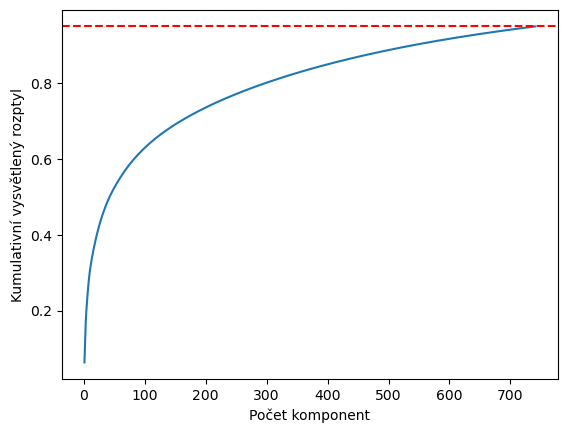

In [9]:
import matplotlib.pyplot as plt

plt.plot(range(1, len(cum_var)+1), cum_var)
plt.axhline(y=0.95, color='r', linestyle='--')
plt.xlabel('Počet komponent')
plt.ylabel('Kumulativní vysvětlený rozptyl')
plt.show()

In [10]:
import xgboost as xgb

rf = xgb.XGBClassifier( random_state=69)
rf.fit(X1, y1)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [11]:
pred = rf.predict(X2)

In [12]:
from sklearn.metrics import matthews_corrcoef, accuracy_score, f1_score

print("Acc:", accuracy_score(pred, y2))
print("Mcc:", matthews_corrcoef(pred, y2))

Acc: 0.9630086313193588
Mcc: 0.0


In [13]:
pred = rf.predict(X3)
print("Acc:", accuracy_score(pred, y3))
print("Mcc:", matthews_corrcoef(pred, y3))

Acc: 0.9652777777777778
Mcc: 0.0


In [ ]:
import xgboost as xgb
from sklearn.metrics import matthews_corrcoef, accuracy_score, f1_score, roc_auc_score
import pandas as pd
import optuna

def objective(trial, X_train, y_train, X_val, y_val):
    """Definice cílové funkce pro Optunu"""

    # Návrh hyperparametrů
    params = {
        'objective': 'binary:logistic',  # Pro binární klasifikaci
        'eval_metric': 'auc',  # Pro binární klasifikaci
        'booster': trial.suggest_categorical('booster', ['gbtree', 'dart']),
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'max_depth': trial.suggest_int('max_depth', 5, 10),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.8, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.8, 1.0),
        'alpha': trial.suggest_float('reg_alpha', 0, 1),  # L1 regularizace
        'lambda': trial.suggest_float('reg_lambda', 0, 1),  # L2 regularizace
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 0, 1),
        'seed': 69,
    }
    model = xgb.XGBClassifier(**params)
    model.fit(X_train, y_train.Y)
    y_pred = model.predict(X_val)
    mcc = matthews_corrcoef(y_val.Y, y_pred)  # Používáme MCC

    return mcc


In [ ]:
study = optuna.create_study(
    study_name="A2AR_xgb_3",  # jméno pro pozdější načtení
    direction="maximize",
    sampler=optuna.samplers.NSGAIISampler(),
    storage="sqlite:///optuna_results.db",
    load_if_exists=True  # pokud už existuje, nepřepíše ji
)

# Spusť optimalizaci
study.optimize(
    lambda trial: objective(trial, X1, y1, X2, y2),
    n_trials=1000
)
print("Best MCC:", study.best_value)
print("Best parameters:", study.best_params)

# Pokud chceš F1 a ACC u nejlepšího modelu:
print("Best F1:", study.best_trial.user_attrs["f1"])
print("Best ACC:", study.best_trial.user_attrs["acc"])

In [ ]:
y1.Y

In [16]:
import numpy as np
best_params =  study.best_params

In [17]:
best_params

{'booster': 'gbtree',
 'n_estimators': 115,
 'learning_rate': 0.05156237868106604,
 'max_depth': 5,
 'min_child_weight': 1,
 'subsample': 0.831779395669562,
 'colsample_bytree': 0.8422901114132939,
 'reg_alpha': 0.9148894494644708,
 'reg_lambda': 0.28864707915353394,
 'scale_pos_weight': 0.7465491976303863}

In [21]:
rf = xgb.XGBClassifier(**best_params, seed=69)
rf.fit(X1, y1)

XGBClassifier(base_score=None, booster='gbtree', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8422901114132939, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05156237868106604,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=1, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=115, n_jobs=None,
              num_parallel_tree=None, ...)

In [22]:
pred = rf.predict(X2)

print("Acc:", accuracy_score(pred, y2))
print("F1:", f1_score(pred, y2))
print("Mcc:", matthews_corrcoef(pred, y2))

Acc: 0.9630086313193588
F1: 0.9811320754716981
Mcc: 0.12197323265411819


In [24]:
pred_test = rf.predict(X3)

print("Acc:", accuracy_score(pred_test, y3))
print("F1:", f1_score(pred_test, y3))
print("Mcc:", matthews_corrcoef(pred_test, y3))

Acc: 0.9664351851851852
F1: 0.9829110194460813
Mcc: 0.17948038815839415
